Importing libaries to be used for this lab

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Question1:Uploading the dataset to Colab

In [ ]:
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

Confirming the dataset has been loaded

In [ ]:
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


Question 2:The number of rows and columns in the dataset.


In [ ]:
df.shape

(5268, 13)

Question 3: Displaying the last 75 rows of the dataset

In [ ]:
# To remove the default limit of number of rows to be displayed in pandas
pd.set_option('display.max_rows',100)
#to display the 75 rows
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
5198,04/16/2008,14:23,"Off Annobon Island, Equatorial Guinea",Military - Government of Equatorial Guinea,NaN,Bata - Annobon Island,Antonov An-32B,3C-5GE,1609,13.0,13.0,0.0,Crashed into the ocean after skidding off the ...
5199,04/28/2008,09:38,"Off Crimea, Black Sea",Naftogaz,NaN,NaN,Mil Mi-8T,UR-24275,98734295,20.0,20.0,0.0,The helicopter crashed after the tail section ...
5200,05/02/2008,10:10,"Near Rumbek, Sudan",Southern Sudan Air Connection,NaN,Wau - Rumbek - Juba,Beechcraft 1900C,5Y-FLX,UC-65,24.0,24.0,0.0,The pilot radioed a control tower in the city ...
5201,05/17/2008,16:30,"Stehekin, Washington",Chelan Air Service,NaN,Chelan - Stehekin,de Havilland Canada DHC-2 Mark I Beaver,N5998Q,1151,5.0,2.0,0.0,The float plane flipped and crashed as it atte...
5202,05/23/2008,01:25,"Billings, Montana",Alpine Aviation,5008,Billings - Great Falls,Beechcraft 1900C,N195GA,U-65,1.0,1.0,0.0,"After taking off and being told to turn left,..."


Question 4:Each column except the first one has some missing data. For each column, name
the most appropriate method for treating the missing data. Justify your choices.

1. The text columns such as( Date ,Time,Location,Operator,Flight,Route,Type, Registration, cn/In, Summary) we carry out mode imputation
 Justification: statistical operations like mean or median cannot be computed. Replacing missing values with a placeholder preserves the row for analysis without inventing false historical details.

2. The Numerical columns such as( Aboard,Fatalities,Ground) we carry out median imputation
Justification: Most crashes involve small planes with very few people, but a few rare crashes involve huge airliners. These huge crashes make the mean artificially high. Using the median gives a much truer picture of a typical crash and avoids filling in missing data with fake, overly high numbers.

Question 5:new dataframe from the raw/uncleaned data called
‘fatality_locations’ with the following columns: ‘Date’,
‘Location’, ‘Aboard’, ‘Fatalities’.

In [ ]:
fatality_locations= df[['Date','Location','Aboard','Fatalities']].copy()

To confirm if data has been copied to Fatalities

In [ ]:
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


Question 6:The date of the highest number of recorded fatalities from this new
dataframe.

In [ ]:
high_fatality=fatality_locations['Fatalities'].idxmax()
date_of_highest_fatality=fatality_locations.loc[high_fatality,'Date']
print(date_of_highest_fatality)

03/27/1977


Question 7:Comparing the number of passengers aboard to the number of fatalities per crash if there are any recorded crashes where there were no fatalities, if so how many

In [ ]:
# Displaying the comparison of the 2 columns abroad and fatality
display(df[['Aboard','Fatalities']].head())

# Finding the crashes with no fatality
Fatality_Crash= df[df['Fatalities']==0]

#Counting the number of crashes with no fatality
Fatality_Crash.count=len(Fatality_Crash)

print("\n", Fatality_Crash.count)

,Aboard,Fatalities
0,2.0,1.0
1,5.0,5.0
2,1.0,1.0
3,20.0,14.0
4,30.0,30.0



 58


Question 8: In the ‘fatality_locations’ dataframe, the location column has data items represented as ‘Region, U.S. State/Country’. Split this column to have two columns of regions and states/countries.

In [ ]:
fatality_locations[['Region', 'Country']] = fatality_locations['Location'].str.split(',', n=1, expand=True)
print(fatality_locations)


            Date                                           Location  Aboard  \
0     09/17/1908                                Fort Myer, Virginia     2.0   
1     07/12/1912                            AtlantiCity, New Jersey     5.0   
2     08/06/1913                 Victoria, British Columbia, Canada     1.0   
3     09/09/1913                                 Over the North Sea    20.0   
4     10/17/1913                         Near Johannisthal, Germany    30.0   
...          ...                                                ...     ...   
5263  05/20/2009                             Near Madiun, Indonesia   112.0   
5264  05/26/2009                  Near Isiro, DemocratiRepubliCongo     4.0   
5265  06/01/2009  AtlantiOcean, 570 miles northeast of Natal, Br...   228.0   
5266  06/07/2009       Near Port Hope Simpson, Newfoundland, Canada     1.0   
5267  06/08/2009                  State of Arunachal Pradesh, India    13.0   

      Fatalities                      Region  \
0  

9.  Order the dataframe by the number of fatalities from highest to lowest and select the first 100.

In [ ]:
fatality_locations = fatality_locations.sort_values('Fatalities', ascending=False).head(100)
print(fatality_locations)

            Date                                           Location  Aboard  \
2963  03/27/1977                           Tenerife, Canary Islands   644.0   
3568  08/12/1985              Mt. Osutaka, near Ueno Village, Japan   524.0   
4455  11/12/1996                           Near Charkhidadri, India   349.0   
2726  03/03/1974                          Near Ermenonville, France   346.0   
3562  06/23/1985            AtlantiOcean, 110 miles West of Ireland   329.0   
3240  08/19/1980                          Near Riyadh, Saudi Arabia   301.0   
3775  07/03/1988     Over the Persian Gulf, near Bandar Abbas, Iran   290.0   
4916  02/19/2003                                 Near Shahdad, Iran   275.0   
3137  05/25/1979                           Chicago O'Hare, Illinois   271.0   
3436  09/01/1983                       Near Sakhalin Island, Russia   269.0   
4249  04/26/1994                          Near Komaki, Aichi, Japan   271.0   
4026  07/11/1991                               Jedda

10.  Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State. [Hint: charts can be generated from the seaborn library]

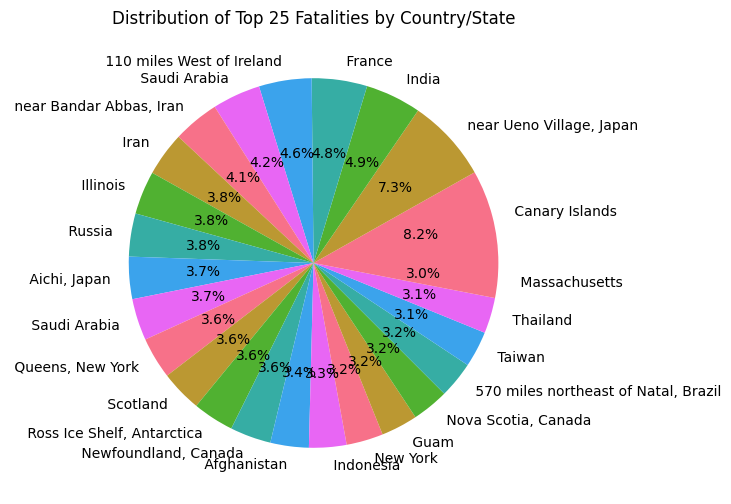

In [ ]:
# Get top 25 rows by fatalities, grouped by Country
#figsize shows the x and y-axis lengths
#sns.color_palette shows the color in which the pie chart will be displayed
#plt.title shows the title of the chart
#plt.show outputs the diagram
top_25 = fatality_locations.nlargest(25, 'Fatalities')

plt.figure(figsize=(6, 6))
plt.pie(top_25['Fatalities'], labels=top_25['Country'], autopct='%1.1f%%', colors=sns.color_palette('husl'))
plt.title('Distribution of Top 25 Fatalities by Country/State')
plt.show()